# KDD Data Analysis and Attack Classification using Machine Learning & Neural Networks
This notebook covers data preprocessing, feature engineering, and training multiple ML models to classify attacks using the KDD dataset.

In [ ]:

import pandas as pd  # Importing pandas for data handling
import numpy as np  # Importing numpy for numerical operations
import seaborn as sns  # Importing seaborn for visualization
import matplotlib.pyplot as plt  # Importing matplotlib for plotting graphs
from sklearn.model_selection import train_test_split  # Splitting dataset into train and test
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Encoding categorical variables and scaling data
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Importing classification models
from sklearn.svm import SVC  # Importing Support Vector Classifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Evaluation metrics
import tensorflow as tf  # TensorFlow for deep learning
from tensorflow import keras  # Keras API for building models
from tensorflow.keras.models import Sequential  # Sequential model type
from tensorflow.keras.layers import Dense, Dropout  # Neural network layers


## Load the KDD dataset from URL

In [ ]:









from sklearn.datasets import fetch_kddcup99
import pandas as pd

data = fetch_kddcup99(percent10=True, as_frame=True)

df = data.frame
df.columns = ["duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
              "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations", "num_shells",
              "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
              "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
              "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
              "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"]

print(df.head())

  duration protocol_type  service   flag src_bytes dst_bytes land  \
0        0        b'tcp'  b'http'  b'SF'       181      5450    0   
1        0        b'tcp'  b'http'  b'SF'       239       486    0   
2        0        b'tcp'  b'http'  b'SF'       235      1337    0   
3        0        b'tcp'  b'http'  b'SF'       219      1337    0   
4        0        b'tcp'  b'http'  b'SF'       217      2032    0   

  wrong_fragment urgent hot  ... dst_host_srv_count dst_host_same_srv_rate  \
0              0      0   0  ...                  9                    1.0   
1              0      0   0  ...                 19                    1.0   
2              0      0   0  ...                 29                    1.0   
3              0      0   0  ...                 39                    1.0   
4              0      0   0  ...                 49                    1.0   

  dst_host_diff_srv_rate dst_host_same_src_port_rate  \
0                    0.0                        0.11   
1   

In [ ]:
# sample 5000 rows to make training faster

# Sample 5000 rows from the DataFrame
df = df.sample(n=5000, random_state=42)  # Use random_state for reproducibility

# Now df_sampled contains your sampled data
df.shape


## Data Preprocessing & Feature Engineering

In [ ]:

# Encoding categorical variables into numeric form
encoder = LabelEncoder()
categorical_columns = ['protocol_type', 'service', 'flag']
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

# Convert labels into binary classification (attack or normal)
df['label'] = df['label'].apply(lambda x: 'normal' if x == 'normal.' else 'attack')
df['label'] = encoder.fit_transform(df['label'])

# Feature Engineering: Creating new features
df['byte_ratio'] = df['src_bytes'] / (df['dst_bytes'] + 1)
df['total_count'] = df['count'] + df['srv_count']
df['error_rate'] = (df['serror_rate'] + df['rerror_rate']) / 2

df.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,byte_ratio,total_count,error_rate
0,0,1,22,9,181,5450,0,0,0,0,...,0.11,0.0,0.0,0.0,0.0,0.0,1,0.033205,16,0.0
1,0,1,22,9,239,486,0,0,0,0,...,0.05,0.0,0.0,0.0,0.0,0.0,1,0.490760,16,0.0
2,0,1,22,9,235,1337,0,0,0,0,...,0.03,0.0,0.0,0.0,0.0,0.0,1,0.175635,16,0.0
3,0,1,22,9,219,1337,0,0,0,0,...,0.03,0.0,0.0,0.0,0.0,0.0,1,0.163677,12,0.0
4,0,1,22,9,217,2032,0,0,0,0,...,0.02,0.0,0.0,0.0,0.0,0.0,1,0.106739,12,0.0


## Splitting Data into Training and Testing Sets

In [ ]:

X = df.drop('label', axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Training Machine Learning Models
Random Forest Classifiers:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

Gradient Boosting Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

Support Vector Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#

In [ ]:

# RandomForest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Gradient Boosting Classifier
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

# Support Vector Machine (SVM)
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


Random Forest Accuracy: 0.9997469763675927
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     79452
           1       1.00      1.00      1.00     19353

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805

Gradient Boosting Accuracy: 0.9993016547745559
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     79452
           1       1.00      1.00      1.00     19353

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805

SVM Accuracy: 0.9973584332776682
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     79452
           1       0.99      1.00      0.99     19353

    accuracy                           1.00     98805
   ma

## Building a Neural Network Classifier

In [ ]:

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


NameError: name 'Sequential' is not defined

## Evaluating Neural Network Performance

In [ ]:

y_pred_nn = (model.predict(X_test) > 0.5).astype("int32")
print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))

# Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Neural Network Training History')
plt.show()


Based on the above code, write your own code to develop other ML or Neural network algorithms from list below.

Machine Learning Algorithms
**bold text**
Decision Tree Classifier:  https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

K-Nearest Neighbors (KNN):  https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

Naive Bayes Classifier: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html


**Deep Learning Models**
Long Short-Term Memory (LSTM): https://keras.io/api/layers/recurrent_layers/lstm/

Convolutional Neural Networks (CNN): https://keras.io/api/layers/convolution_layers/convolution1d/

Transformers (Hugging Face Transformers)

**Important: Lab-Logbbok requirement**

Provide a bar graph comparing accuracy, precicion, recall, and f-score for various AI models




Decision Tree
Accuracy : 0.996
Precision: 0.9948186528497409
Recall   : 0.9846153846153847
F1-Score : 0.9896907216494846

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       805
           1       0.99      0.98      0.99       195

    accuracy                           1.00      1000
   macro avg       1.00      0.99      0.99      1000
weighted avg       1.00      1.00      1.00      1000

Confusion Matrix:
[[804   1]
 [  3 192]]

KNN
Accuracy : 0.998
Precision: 0.9898477157360406
Recall   : 1.0
F1-Score : 0.9948979591836735

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       805
           1       0.99      1.00      0.99       195

    accuracy                           1.00      1000
   macro avg       0.99      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

Confusion Matrix:
[[803   2]
 [  0 195

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9325 - loss: 0.2178 - val_accuracy: 0.9930 - val_loss: 0.0320
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9905 - loss: 0.0399 - val_accuracy: 0.9940 - val_loss: 0.0162
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9930 - loss: 0.0319 - val_accuracy: 0.9980 - val_loss: 0.0102
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9942 - loss: 0.0299 - val_accuracy: 0.9990 - val_loss: 0.0077
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9955 - loss: 0.0198 - val_accuracy: 0.9990 - val_loss: 0.0070
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9960 - loss: 0.0171 - val_accuracy: 0.9990 - val_loss: 0.0068
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9965 - loss: 0.0136 - val_accuracy: 0.9990 - val_loss: 0.0065
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9967 - loss: 0.0227 - val_accuracy: 0.9990 - val_

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9312 - loss: 0.2776 - val_accuracy: 0.9760 - val_loss: 0.1225
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9730 - loss: 0.1091 - val_accuracy: 0.9830 - val_loss: 0.0908
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9765 - loss: 0.0787 - val_accuracy: 0.9740 - val_loss: 0.0587
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9845 - loss: 0.0487 - val_accuracy: 0.9920 - val_loss: 0.0277
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9875 - loss: 0.0377 - val_accuracy: 0.9920 - val_loss: 0.0243
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9870 - loss: 0.0317 - val_accuracy: 0.9840 - val_loss: 0.0252
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9865 - loss: 0.0374 - val_accuracy: 0.9920 - val_loss: 0.0196
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9885 - loss: 0.0311 - val_accuracy: 0.987

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9532 - loss: 0.1562 - val_accuracy: 0.9940 - val_loss: 0.0301
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9912 - loss: 0.0441 - val_accuracy: 0.9860 - val_loss: 0.0354
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9927 - loss: 0.0253 - val_accuracy: 0.9940 - val_loss: 0.0154
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9950 - loss: 0.0300 - val_accuracy: 0.9960 - val_loss: 0.0193
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9952 - loss: 0.0166 - val_accuracy: 0.9960 - val_loss: 0.0112
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9958 - loss: 0.0221 - val_accuracy: 0.9960 - val_loss: 0.0100
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9967 - loss: 0.0168 - val_accuracy: 0.9960 - val_loss: 0.0131
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9967 - loss: 0.0120 - val_accuracy: 0.9940 - val_

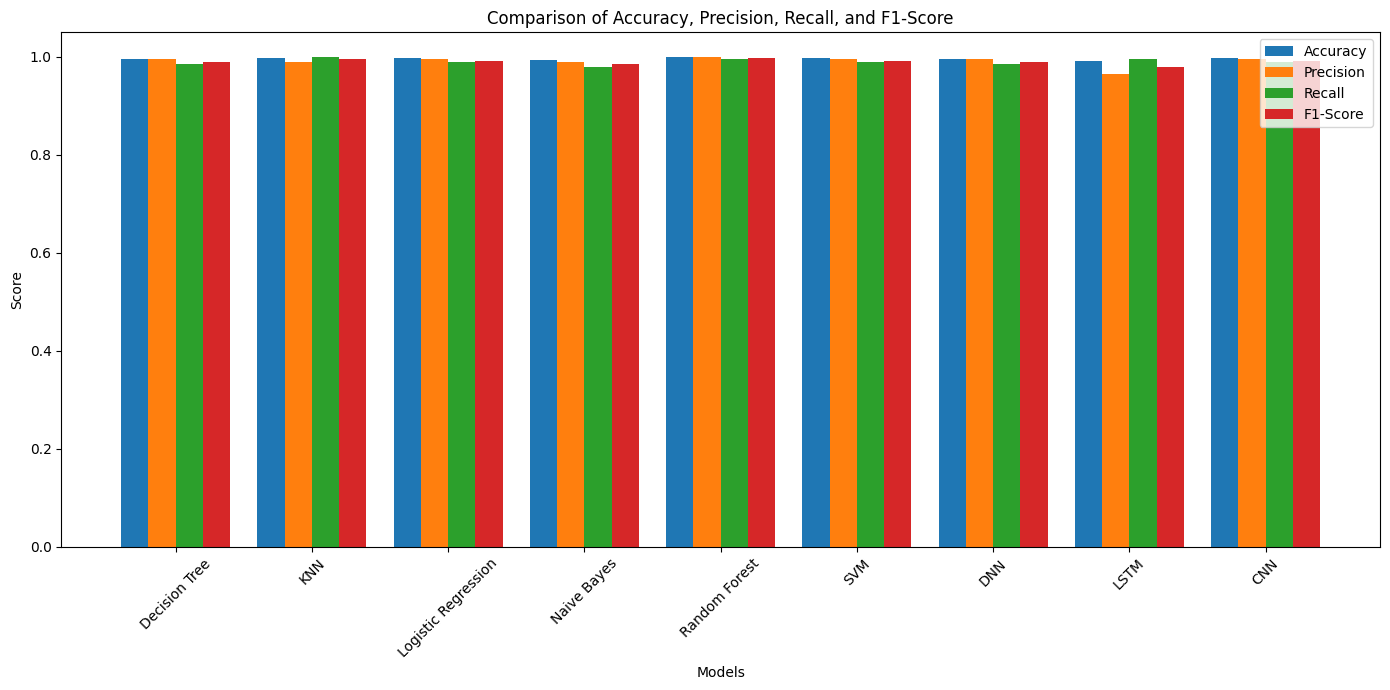

In [1]:
# ============================================================
# INTRUSION DETECTION USING MULTIPLE ML / DL MODELS
# WITH BAR GRAPH FOR ACCURACY, PRECISION, RECALL, F1-SCORE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_kddcup99
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Machine Learning Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Conv1D, MaxPooling1D, Flatten

# ============================================================
# 1. LOAD DATASET
# ============================================================
data = fetch_kddcup99(percent10=True, as_frame=True)
df = data.frame.copy()

df.columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"
]

# Take sample for faster training
df = df.sample(n=5000, random_state=42).reset_index(drop=True)

# ============================================================
# 2. PREPROCESSING
# ============================================================

# Decode byte values if needed
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

# Encode categorical columns
categorical_columns = ['protocol_type', 'service', 'flag']
for col in categorical_columns:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])

# Convert label into binary classification
df['label'] = df['label'].apply(lambda x: 'normal' if x == 'normal.' else 'attack')
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])  # normal=1 / attack=0 or vice versa

# Feature Engineering
df['byte_ratio'] = df['src_bytes'] / (df['dst_bytes'] + 1)
df['total_count'] = df['count'] + df['srv_count']
df['error_rate'] = (df['serror_rate'] + df['rerror_rate']) / 2

# Features and target
X = df.drop('label', axis=1)
y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# 3. FUNCTION TO CALCULATE METRICS
# ============================================================
results = []

def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='binary', zero_division=0)
    recall = recall_score(y_true, y_pred, average='binary', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-Score :", f1)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))


# ============================================================
# 4. MACHINE LEARNING MODELS
# ============================================================

# 4.1 Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)
evaluate_model("Decision Tree", y_test, y_pred_dt)

# 4.2 KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
evaluate_model("KNN", y_test, y_pred_knn)

# 4.3 Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
evaluate_model("Logistic Regression", y_test, y_pred_lr)

# 4.4 Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred_nb = nb_model.predict(X_test_scaled)
evaluate_model("Naive Bayes", y_test, y_pred_nb)

# 4.5 Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
evaluate_model("Random Forest", y_test, y_pred_rf)

# 4.6 SVM
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
evaluate_model("SVM", y_test, y_pred_svm)

# ============================================================
# 5. DEEP NEURAL NETWORK (DENSE)
# ============================================================
dnn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_dnn = dnn_model.fit(
    X_train_scaled, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

y_pred_dnn = (dnn_model.predict(X_test_scaled) > 0.5).astype("int32").flatten()
evaluate_model("DNN", y_test, y_pred_dnn)

# ============================================================
# 6. PREPARE DATA FOR LSTM AND CNN
# reshape to 3D => (samples, timesteps/features, channels)
# ============================================================
X_train_dl = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_dl = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# ============================================================
# 7. LSTM MODEL
# ============================================================
lstm_model = Sequential([
    LSTM(64, input_shape=(X_train_dl.shape[1], 1)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_lstm = lstm_model.fit(
    X_train_dl, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_dl, y_test),
    verbose=1
)

y_pred_lstm = (lstm_model.predict(X_test_dl) > 0.5).astype("int32").flatten()
evaluate_model("LSTM", y_test, y_pred_lstm)

# ============================================================
# 8. CNN MODEL
# ============================================================
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_dl.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_cnn = cnn_model.fit(
    X_train_dl, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_dl, y_test),
    verbose=1
)

y_pred_cnn = (cnn_model.predict(X_test_dl) > 0.5).astype("int32").flatten()
evaluate_model("CNN", y_test, y_pred_cnn)

# ============================================================
# 9. RESULTS TABLE
# ============================================================
results_df = pd.DataFrame(results)
print("\nFinal Comparison Table:")
print(results_df)

# ============================================================
# 10. BAR GRAPH FOR ACCURACY, PRECISION, RECALL, F1-SCORE
# ============================================================
x = np.arange(len(results_df["Model"]))
width = 0.2

plt.figure(figsize=(14, 7))
plt.bar(x - 1.5*width, results_df["Accuracy"], width, label='Accuracy')
plt.bar(x - 0.5*width, results_df["Precision"], width, label='Precision')
plt.bar(x + 0.5*width, results_df["Recall"], width, label='Recall')
plt.bar(x + 1.5*width, results_df["F1-Score"], width, label='F1-Score')

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Comparison of Accuracy, Precision, Recall, and F1-Score")
plt.xticks(x, results_df["Model"], rotation=45)
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()